<a href="https://colab.research.google.com/github/ParushiSrivastava/PARUSHI.23FE10CSE00380/blob/main/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np



from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
glioma_grading_clinical_and_mutation_features = fetch_ucirepo(id=759)

# data (as pandas dataframes)
X = glioma_grading_clinical_and_mutation_features.data.features
y = glioma_grading_clinical_and_mutation_features.data.targets

# metadata
print(glioma_grading_clinical_and_mutation_features.metadata)

# variable information
print(glioma_grading_clinical_and_mutation_features.variables)


{'uci_id': 759, 'name': 'Glioma Grading Clinical and Mutation Features', 'repository_url': 'https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/759/data.csv', 'abstract': 'Gliomas are the most common primary tumors of the brain. They can be graded as LGG (Lower-Grade Glioma) or GBM (Glioblastoma Multiforme) depending on the histological/imaging criteria. Clinical and molecular/mutation factors are also very crucial for the grading process. Molecular tests are expensive to help accurately diagnose glioma patients.    In this dataset, the most frequently mutated 20 genes and 3 clinical features are considered from TCGA-LGG and TCGA-GBM brain glioma projects.  The prediction task is to determine whether a patient is LGG or GBM with a given clinical and molecular/mutation features. The main objective is to find the optimal subset of mutation genes and clinical features for the glioma grading 

In [ ]:
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/tmp/ipykernel_17673/1523977689.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])


In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means Labels:")
print(kmeans_labels[:10])

K-Means Labels:
[0 0 0 0 0 0 0 0 0 0]


In [ ]:
hc = AgglomerativeClustering(
    n_clusters=2
)

hc_labels = hc.fit_predict(X_scaled)

print("Hierarchical Labels:")
print(hc_labels[:10])

Hierarchical Labels:
[0 0 0 1 0 0 0 0 0 1]


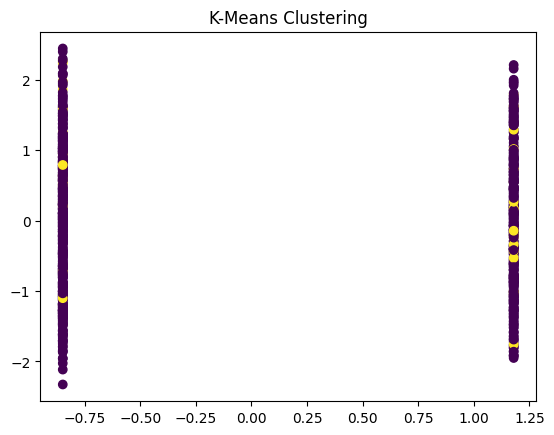

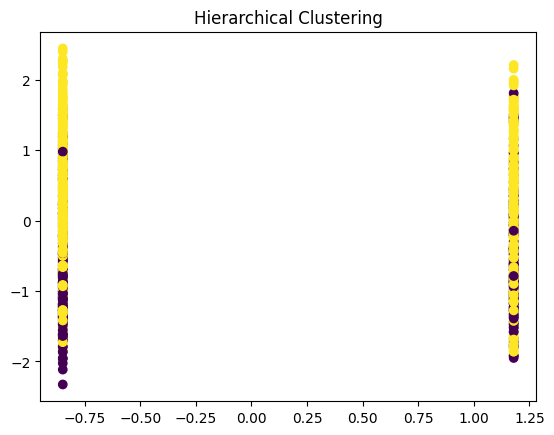

In [ ]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels
)

plt.title("K-Means Clustering")
plt.show()


plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=hc_labels
)

plt.title("Hierarchical Clustering")
plt.show()